# Confronto semplice tra Batch, Mini-batch e Stochastic Gradient Descent

In questo notebook confrontiamo **3 varianti del gradient descent** su una funzione costo con **2 variabili** ($w_1, w_2$).
Obiettivi:
- capire la differenza pratica tra Batch GD, Mini-batch GD e SGD
- osservare come cambia la discesa della cost function
- visualizzare il percorso dei parametri su un contour plot 2D

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use("seaborn-v0_8")

## 1) Dataset sintetico e funzione costo

Usiamo una regressione lineare senza bias:

$$
\hat{y} = w_1 x_1 + w_2 x_2 = (x_1, \  x_2)\cdot (w_1, \ w_2)^T
$$

La cost function (MSE) dipende quindi da **due soli parametri**:

$$
C(w_1, w_2) = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2,
$$

dove $N=1$ per SGD, $N$ coincide con $N_{train}$ (numero di dati nel training set) per vanilla gradient descent, e $1<N<N_{train}$ per mini-batch.

Poi visualizzeremo il processo di training nel piano bidimensionale $(w_1, w_2)$.

In [4]:
# Generazione dati
n_samples = 500
X = np.random.randn(n_samples, 2)
true_w = np.array([3.0, -2.0])
noise = np.random.randn(n_samples)
y = X @ true_w + noise

# Funzioni utili
def predict(X, w):
    return X @ w

def cost_mse(X, y, w):
    err = predict(X, w) - y
    return np.mean(err ** 2)

def gradient_mse(X_batch, y_batch, w):
    err = X_batch @ w - y_batch
    return (2.0 / len(X_batch)) * (X_batch.T @ err)

print("Forma X:", X.shape)
print("Pesi reali:", true_w)

Forma X: (500, 2)
Pesi reali: [ 3. -2.]


## 2) Implementazione dei 3 tipi di Gradient Descent

- **Batch GD**: usa tutti i dati a ogni aggiornamento
- **Mini-batch GD**: usa piccoli gruppi di dati
- **Stochastic GD (SGD)**: usa un solo campione per volta

Per confrontarli in modo corretto, registriamo:
- traiettoria dei pesi $(w_1, w_2)$
- valore della cost function a ogni epoca (calcolato su tutto il dataset)

# Esercizio: 

1) Scrivere una funzione python (con anche altre funzioni ausiliare se necessario) che effettua il training del modello definito prima. La funzione calcola il gradiente e aggiorna i parametri tramite la regola di update ordinaria. Definisci tutti gli altri "iperparametri" che servono per questo scopo. La funzione deve accettare un parametro di input "mode" che gestisce i 3 tipi di gradient descent visti prima.

2) Mostrare il grafico del percorso seguito dai parametri aggiornati, epoca per epoca, in un piano 2d dei parametri $(w_1, w_2)$. Il grafico mostrerà 3 line plot, uno per ogni tipo di gradient descent.

3) Mostrare il grafico della Cost function come funzione dell'epoca di training. Il grafico mostrerà 3 line plot, uno per ogni tipo di gradient descent.

In [7]:
def batch(X, y, w, learning_rate=0.01, epochs=100):
    pesi = []
    costi = []

    for _ in range(epochs):
        grad = gradient_mse(X, y, w)
        w = w - learning_rate * grad

        pesi.append(w.copy())
        costi.append(cost_mse(X, y, w))
    return pesi, costi

def mini_batch(X, y, w, learning_rate=0.01, epochs=100, batch_size=32):
    pesi = []
    costi = []

    for _ in range(epochs):
        indices = np.random.randint(0, len(X), size=batch_size)
        X_batch = X[indices]
        y_batch = y[indices]

        grad = gradient_mse(X_batch, y_batch, w)
        w = w - learning_rate * grad

        pesi.append(w.copy())
        costi.append(cost_mse(X, y, w))

    return pesi, costi

def sgd(X, y, w, learning_rate=0.01, epochs=100):
    pesi = []
    costi = []

    for _ in range(epochs):
        index = np.random.randint(0, len(X))
        X_batch = X[index:index+1]
        y_batch = y[index:index+1]

        grad = gradient_mse(X_batch, y_batch, w)
        w = w - learning_rate * grad

        pesi.append(w.copy())
        costi.append(cost_mse(X, y, w))

    return pesi, costi

# inizializzazione pesi iniziale

w0 = np.zeros(2)

# eseguiamo il traning per i 3 metodi

pesi_batch, costi_batch = batch(X, y, w0)
pesi_mini, costi_mini = mini_batch(X, y, w0)
pesi_sgd, costi_sgd = sgd(X, y, w0)


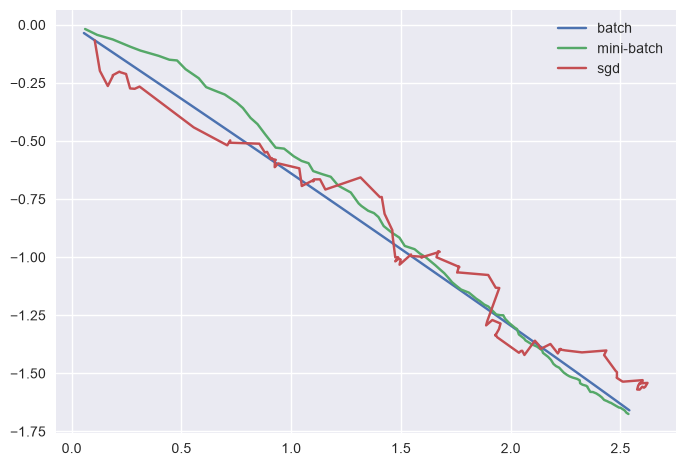

In [8]:
# Grafico 1

plt.plot([p[0] for p in pesi_batch], [p[1] for p in pesi_batch], label="batch")
plt.plot([p[0] for p in pesi_mini], [p[1] for p in pesi_mini], label="mini-batch")
plt.plot([p[0] for p in pesi_sgd], [p[1] for p in pesi_sgd], label="sgd")
plt.legend()
plt.show()

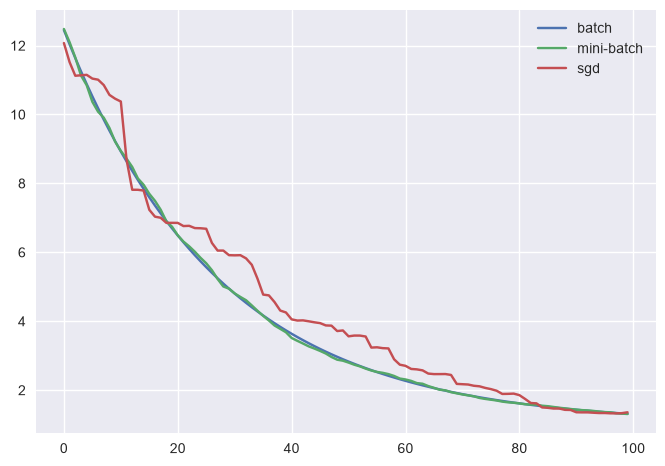

In [9]:
# Grafico 2

plt.plot(costi_batch, label="batch")
plt.plot(costi_mini, label="mini-batch")
plt.plot(costi_sgd, label="sgd")
plt.legend()
plt.show()

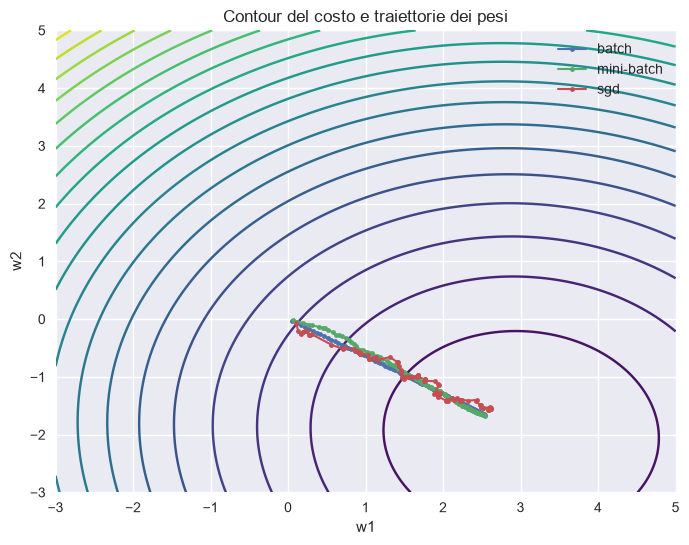

In [10]:
# Grafico aggiuntivo: contour del costo + traiettorie dei pesi

xx = np.linspace(-3, 5, 200)
yy = np.linspace(-3, 5, 200)
W1, W2 = np.meshgrid(xx, yy)
Z = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_grid = np.array([W1[i, j], W2[i, j]])
        Z[i, j] = cost_mse(X, y, w_grid)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(W1, W2, Z, levels=20, cmap="viridis")
ax.set_title("Contour del costo e traiettorie dei pesi")
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.grid(True)

# funzione di utilità per plottare una traiettoria se disponibile
def _plot_traj(pesi, label, color=None):
    if len(pesi) == 0:
        return
    arr = np.array(pesi)
    if arr.ndim == 1:
        return
    ax.plot(arr[:, 0], arr[:, 1], marker='.', linewidth=1.5, label=label, color=color)

_plot_traj(pesi_batch, "batch")
_plot_traj(pesi_mini, "mini-batch")
_plot_traj(pesi_sgd, "sgd")

ax.legend()
plt.show()
